<a href="https://colab.research.google.com/github/nicolas123aguilar123-jpg/Practica-aprendizaje-no-supervisado---Sales_Records/blob/main/Proyecto_Sales_Record_Sarai_Alvarez_Nicolas_Aguilar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PROYECTO DE APRENDIZAJE NO SUPERVISADO

Estudiantes:
- Nicolas Gonzalo Aguilar Arimoza
- Sarai Leslie Alvarez Rosas

In [1]:
#Paso 1: CARGAR EL DATASET

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs



# TODO: carga tu dataset
df = pd.read_csv('/Sales_Records.csv')

df_muestraMediana = df.sample(n=1000, random_state=42)
df_muestraPequena = df.sample(n=30, random_state=42)

df.head()


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,M,7/27/2012,443368995,7/28/2012,1593,9.33,6.92,14862.69,11023.56,3839.13
1,Middle East and North Africa,Morocco,Clothes,Online,M,9/14/2013,667593514,10/19/2013,4611,109.28,35.84,503890.08,165258.24,338631.84
2,Australia and Oceania,Papua New Guinea,Meat,Offline,M,5/15/2015,940995585,6/4/2015,360,421.89,364.69,151880.40,131288.40,20592.00
3,Sub-Saharan Africa,Djibouti,Clothes,Offline,H,5/17/2017,880811536,7/2/2017,562,109.28,35.84,61415.36,20142.08,41273.28
4,Europe,Slovakia,Beverages,Offline,L,10/26/2016,174590194,12/4/2016,3973,47.45,31.79,188518.85,126301.67,62217.18


## Justificaion Escrita
 ### - ¿por qué elegiste este dataset?
 Utilizamos este dataset porque contine multiples datos sobre las ventas globales de cada producto, segun su pais y region , y al no tener una variable objetivo podemosusarlo en un entrenamiento no supervizado.

 ### - ¿qué tipo de grupos esperás
Esperamos obtener:
- en que paises se venden mas productos? Que productos?
- en que paises se venden menos productos? Que productos?
- que productos son los mas vendidos a nivel global?
- que canal de ventas son las mas utilizadas para la venta de productos?
- En que fechas hay mas pedidos?
- que pedidos tienen mas prioridad?


In [7]:
## Paso 2 — Exploración de datos (EDA)
df.describe()
#rangos el min y el max

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06
mean,5.493520e+08,4998.867302,266.025488,187.522978,1.329563e+06,9.372671e+05,3.922956e+05
std,2.599397e+08,2885.334142,216.987966,175.650798,1.468527e+06,1.148954e+06,3.788199e+05
min,1.000012e+08,1.000000,9.330000,6.920000,9.330000e+00,6.920000e+00,2.410000e+00
25%,3.239629e+08,2502.000000,81.730000,35.840000,2.778672e+05,1.617289e+05,9.510480e+04
50%,5.486524e+08,4998.000000,154.060000,97.440000,7.844445e+05,4.667818e+05,2.810549e+05
75%,7.745981e+08,7496.000000,421.890000,263.330000,1.822444e+06,1.196327e+06,5.653076e+05
max,9.999999e+08,10000.000000,668.270000,524.960000,6.682700e+06,5.249600e+06,1.738700e+06


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Region          1000000 non-null  object 
 1   Country         1000000 non-null  object 
 2   Item Type       1000000 non-null  object 
 3   Sales Channel   1000000 non-null  object 
 4   Order Priority  1000000 non-null  object 
 5   Order Date      1000000 non-null  object 
 6   Order ID        1000000 non-null  int64  
 7   Ship Date       1000000 non-null  object 
 8   Units Sold      1000000 non-null  int64  
 9   Unit Price      1000000 non-null  float64
 10  Unit Cost       1000000 non-null  float64
 11  Total Revenue   1000000 non-null  float64
 12  Total Cost      1000000 non-null  float64
 13  Total Profit    1000000 non-null  float64
dtypes: float64(5), int64(2), object(7)
memory usage: 106.8+ MB


In [9]:
# cuántas filas y columnas tiene?
rows = df.shape[0]
col = df.shape[1]

print(f"filas: {rows}")
print(f"columnas: {col}")

filas: 1000000
columnas: 14


In [10]:
#tiene valores nulos?
df.isna().sum()

,0
Region,0
Country,0
Item Type,0
Sales Channel,0
Order Priority,0
Order Date,0
Order ID,0
Ship Date,0
Units Sold,0
Unit Price,0


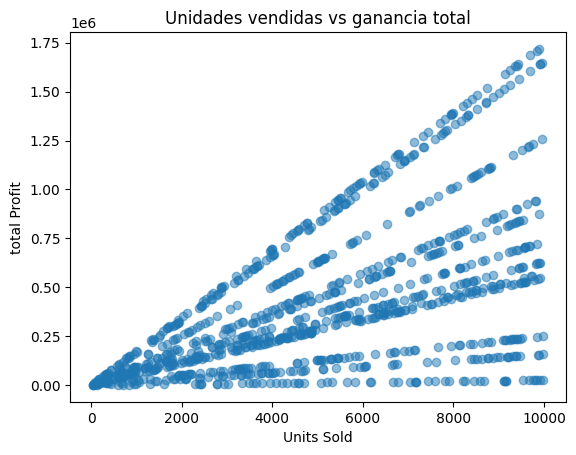

In [11]:
 # grafico exploratorio de dispersion 1
#muchos datos

#df_muestra = df.sample(n=5000, random_state=42)
plt.scatter(df_muestraMediana['Units Sold'], df_muestraMediana['Total Profit'], alpha=0.5)
plt.xlabel('Units Sold')# unidades vendidas
plt.ylabel('total Profit')#ganancia total/beneficio
plt.title('Unidades vendidas vs ganancia total')
plt.show()

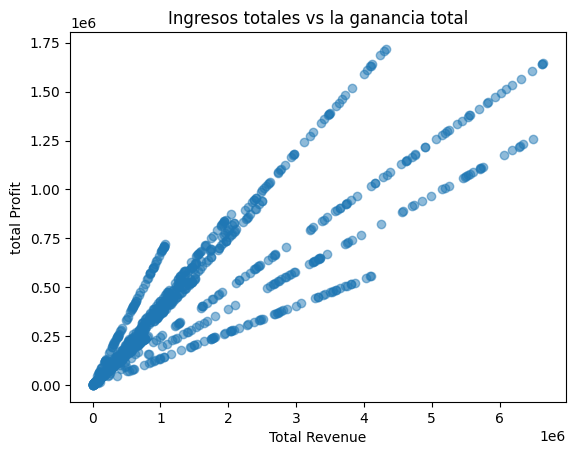

In [12]:
# grafico exploratorio  de dispersion 2
plt.scatter(df_muestraMediana['Total Revenue'], df_muestraMediana['Total Profit'], alpha=0.5)
plt.xlabel('Total Revenue')#ingresos totales
plt.ylabel('total Profit')#ganancia total/beneficio
plt.title('Ingresos totales vs la ganancia total')
plt.show()

## identifica
- ¿cuántas filas y columnas tiene?
Tenemos :
filas: 1000000
columnas: 14

- ¿hay valores nulos?
El dataset k elegimos no tiene valores nulo

- ¿qué rango tiene cada variable numérica?
tenemos rangos de variables desde 1 hasta 1 millon

### Justificación escrita:
-  describe con tus propias palabras qué observas en tus gráficos. ¿Ya
se nota a simple vista alguna agrupación o los datos parecen "una sola nube"? No copies
una descripción genérica — decime específicamente qué ves en TUS datos.





Respuesta:
grafico de dispersion1: aqui manejamos 2 variables que son Units Sold y Total profit , estas se relacionan entre si teniendo la ganancia total de los productos vendidos.Lo que podemos observar es que mientrsa mas unidades vendidas de un producto mas ganancias se tendra , pero tambien nos muestra que hay productos que aunque se vendan bien no se obtiene una ganancia significativa

Grafico de dispersion 2:
qui analizamos los ingresos totales y la ganancia total, iondica quer mientras mas ingresos mas ganancias se obtiene.


In [13]:
#Paso 3 — Selección de variables y escalado de todos los datos

cols = ['Units Sold','Unit Price','Total Revenue','Total Profit']
x = df[cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)






In [14]:
#muestra 1
cols = ['Units Sold','Unit Price','Total Revenue','Total Profit']
x_scaled_muestraMediana = df_muestraMediana[cols]
scaler = StandardScaler()
x_scaled_muestraMediana = scaler.fit_transform(x_scaled_muestraMediana)

#muestra 2
cols = ['Units Sold','Unit Price','Total Revenue','Total Profit']
x_scaled_muestraPequena = df_muestraPequena[cols]
scaler = StandardScaler()
x_scaled_muestraPequena = scaler.fit_transform(x_scaled_muestraPequena)

In [15]:

df[cols].describe()

,Units Sold,Unit Price,Total Revenue,Total Profit
count,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06
mean,4998.867302,266.025488,1.329563e+06,3.922956e+05
std,2885.334142,216.987966,1.468527e+06,3.788199e+05
min,1.000000,9.330000,9.330000e+00,2.410000e+00
25%,2502.000000,81.730000,2.778672e+05,9.510480e+04
50%,4998.000000,154.060000,7.844445e+05,2.810549e+05
75%,7496.000000,421.890000,1.822444e+06,5.653076e+05
max,10000.000000,668.270000,6.682700e+06,1.738700e+06


### Justificación escrita: ¿por qué elegiste esas variables y no otras del dataset? Mirando los

- Elegimos las variables de Units sold, total revenue, unit price , total profit , porque son la cantidad vendida , los ingresos obtenidos , el precio de cada producto y las ganancias totales , con esto podemos ver como son  las ventas a nivel gobal, no elegimos las demas porquealgunas son fechas o id de identificacion que son catergoricas y no sirven para usarse en clustering

###  ¿por qué es necesario escalar en tu caso particular (compara los rangos numéricamente, no digas solo "porque hay que escalar")?

necesitamos escalar porque las variables que utilizaremos para el cluster que son 'Units Sold','Unit Price','Total Revenue','Total Profit' tienen rangos diferentes , por  ejemplo "Unit price" llega a 668 mientras que "total revenue" supera los 6 millones, entonces si no escalamos influira al momento de segmentar los grupos.

In [16]:
#Paso 4 — K-Means con varios valores de k
#k donde disminuye lento?  codo
inercias = []
for k in range(2, 8):#
  kmeans= KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inercias.append(kmeans.inertia_)
  print(f"k={k}: inercia = {kmeans.inertia_:.1f}")

  #k=4: inercia = 1022332.4

k=2: inercia = 2111307.9
k=3: inercia = 1431246.3
k=4: inercia = 1022332.4
k=5: inercia = 826455.2
k=6: inercia = 662236.6
k=7: inercia = 569573.7


In [17]:
#prediccion
km4= KMeans(n_clusters=4, random_state=42,n_init=10)
df['cluster_kmeans']=km4.fit_predict(X_scaled)
df['cluster_kmeans'].value_counts().sort_index()


,count
cluster_kmeans,
0,174129
1,152412
2,326091
3,347368


In [18]:
df.groupby('cluster_kmeans')[cols].mean().round(1)

#detalle de cada grupo


,Units Sold,Unit Price,Total Revenue,Total Profit
cluster_kmeans,,,,
0,2691.5,529.8,1385029.9,312289.0
1,7543.5,566.8,4238276.1,1054558.2
2,7535.5,144.0,1057206.9,421287.0
3,2657.8,116.4,281197.4,114609.8


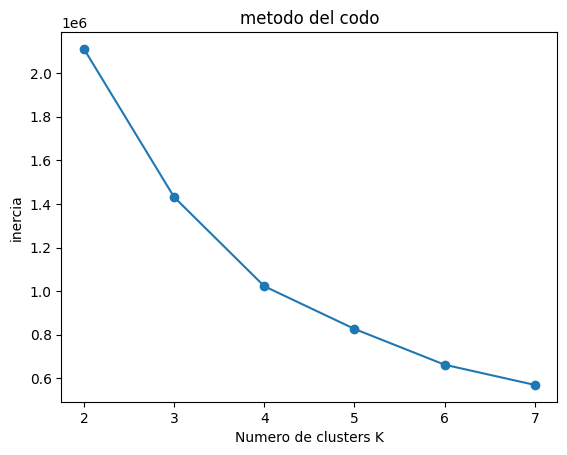

In [19]:
#grafico
plt.plot(range(2,8), inercias, marker='o')
plt.xlabel('Numero de clusters K')
plt.ylabel('inercia')
plt.title('metodo del codo')
plt.show()

In [20]:
#silhouette:k tan bien estan agrupados los datos la calidad

#for k in range(2,8):
 # kmeans = KMeans(n_clusters=k, random_state=42, n_init=10 )
 # sil = silhouette_score(X_scaled, kmeans.fit_predict(X_scaled))
 # print(f"k={k}:   silhouette = {sil:.3f}")


for k in range(2,8):
  kmeans = KMeans(n_clusters=k, random_state=42 )#n_init=10
  sil = silhouette_score(x_scaled_muestraMediana, kmeans.fit_predict(x_scaled_muestraMediana))
  print(f"k={k}:   silhouette = {sil:.3f}")

k=2:   silhouette = 0.455
k=3:   silhouette = 0.387
k=4:   silhouette = 0.422
k=5:   silhouette = 0.371
k=6:   silhouette = 0.386
k=7:   silhouette = 0.397


### Justificación escrita:
- ¿qué k elegiste y qué mostraron el codo y el silhouette score para
justificar esa elección? Si ambas métricas no coinciden en el mismo k, explica cuál
priorizaste y por qué.

aplicamos el k-means con el metodo del codo,en el que elegimos el K= 4 como numero de clusters porque desde ahi la inercia ya no disminuye tanto en comparacion con k=3 y k=2 , En silhouette nos indica k k=2 es el que tiene el valormas alto, seguido de k=4. entonces tener 4 clusters puede darmos una segmentacion mas detallada de todos los datos en comparacion de si elegimos k=2.


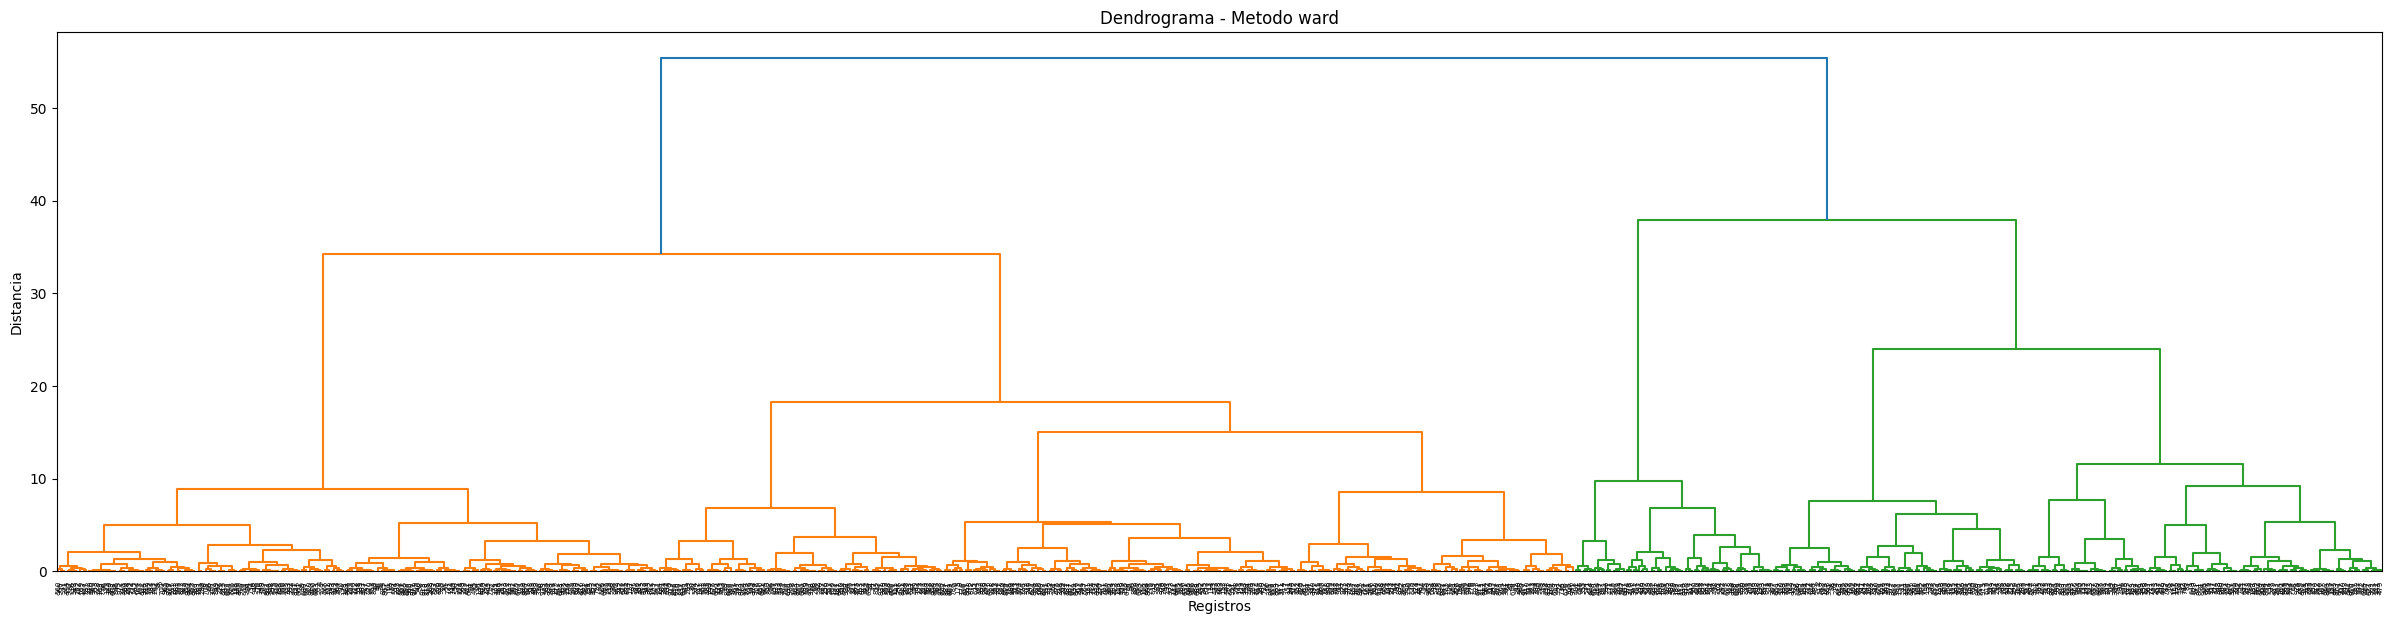

In [27]:
#Paso 5 — Clustering jerárquico (para contrastar)

from scipy.cluster.hierarchy import dendrogram, linkage

import matplotlib.pyplot as plt

#muestra para el dendrograma
Z = linkage(x_scaled_muestraMediana, 'ward')

plt.figure(figsize=(30,7))
dendrogram(Z)

plt.title('Dendrograma - Metodo ward')
plt.xlabel('Registros')
plt.ylabel('Distancia')
plt.show()



### ¿los grupos que forma el clustering jerárquico son parecidos a los de K-Means o muy distintos? ¿A qué crees que se debe eso?
Si son parecidos pero no son iguales en el dendrograma vemos como se van dividiendo el arbol, vemos cada cluster porque se van agrupando dependiento su similitud y en el K-means los datos de cada cluster se forma agrupandose en su centro.


In [22]:
#Paso 6 — DBSCAN y detección de outliers
eps  =[0.3, 0.50,0.8]
min_samples = [5, 10 , 30]
for eps, min_samples in zip(eps , min_samples):
  clustering = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(x_scaled_muestraMediana)#X_scaled
  n_clusters = len(set(clustering))- (1 if -1 in clustering else 0)
  outliers = np.sum(clustering == -1)
  print(f"eps: {eps}")
  print(f"min_samples: {min_samples}")
  print(f"clusters: {n_clusters}")
  print(f"outliers: {outliers}")
  print(f"---------")


# mil   x_scaled_muestraMediana  eps 0>1    min sample 5   10   30
#millon   x_scaled  eps 0>1    min sample 100 200


eps: 0.3
min_samples: 5
clusters: 8
outliers: 1
---------
eps: 0.5
min_samples: 10
clusters: 4
outliers: 1
---------
eps: 0.8
min_samples: 30
clusters: 3
outliers: 47
---------


In [23]:

fila = df_muestraMediana[clustering == -1].index
print(f"fila {fila}")
#fila 659806
#Central America and the Caribbean -Region
#	Costa Rica	- Country
# Baby Food -tem Type
#	Online -  Sales Channel
# H   - Order Priority
# 	8/9/2015 -Order Date
#	971191680	Order ID
# 9/24/2015  Ship Date
# 	6055 Units Sold
#	255.28  Unit Price
#	159.42	 Unit Cost
# 1545720.4	 -Total Revenue
# 965288.1 -total Cost
# 580432.3  -Total Profit


fila Index([659806, 625691, 926625, 992619, 777379, 622549, 597098, 143248, 716008,
       540478, 394957, 489113, 723570, 858787, 605877,  84894, 742364, 474533,
       771749, 287574, 139427, 166604, 906538, 775108, 840745,  60540, 904743,
       321778, 865260, 224870, 547779, 173032, 311453, 125999, 244781,  83047,
       100488,  41377, 358246, 422040, 125786, 977500, 516705, 610458, 351344,
       811161, 345838],
      dtype='int64')


### Justificación escrita: ¿cuántos outliers detectó tu configuración final? Revisa esas filas
debido a que el dataset tiene 1 millon de datos , al ejecutar DBSCAN usando todos los registros(X_scaled) ocaciona  alto consumo de memoria. e or eso que nos muestra un mensaje de "Tu sesión falló porque se usó toda la RAM disponible."

entonces optamos por usar nuestra muestra media de mil datos que es x_scaled_muestraMediana  la cual nos muestra lo siguiente:


- eps: 0.3
- min_samples: 5
- clusters: 8
- outliers: 1
---------
- eps: 0.5
- min_samples: 10
- clusters: 4
- outliers: 1
---------
- eps: 0.8
- min_samples: 30
- clusters: 3
- outliers: 47
---------

# específicas — ¿tiene sentido que sean atípicas dado lo que sabés del tema? Si DBSCAN
en la ultima ejecucion de DBSCAN entontramos 47 outliers , y al reviar uno de ellos  vemos k tienen alto unit sold y alto total revenue  entonces son valores grandes comparados on los otros datos.

varianza componente 1: 0.682
varianza componente 2: 0.258
varianza total: 0.940


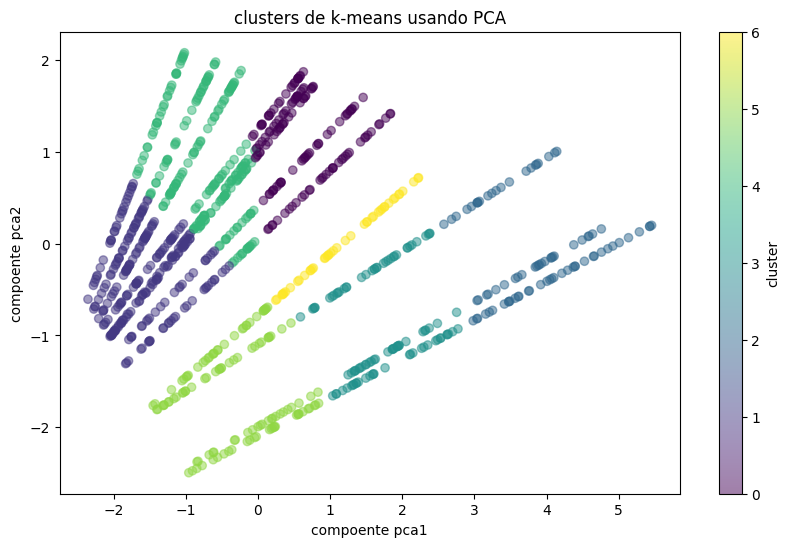

In [24]:
#Paso 7 — Reducción de dimensionalidad y visualización
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#km4= KMeans(n_clusters=4, random_state=42,n_init=10)
v=kmeans.fit_predict(x_scaled_muestraMediana)  #kmeas

pca = PCA(n_components =2)
x_pca =pca.fit_transform(x_scaled_muestraMediana)

print(f"varianza componente 1: {pca.explained_variance_ratio_[0]:.3f}")#info
print(f"varianza componente 2: {pca.explained_variance_ratio_[1]:.3f}")#info
print(f"varianza total: {pca.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(10,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c=v, alpha=0.5)

plt.xlabel('compoente pca1')
plt.ylabel('compoente pca2')
plt.title('clusters de k-means usando PCA')

plt.colorbar(label = 'cluster')
plt.show()



### Justificación escrita: ¿qué porcentaje de la información original conservan tus 2 componentes?
alm aplicar el pca y dividir nuestras variables en 2 componentes nos muestra que el PCA1  tiene el 0.682 % de la informacion y el PCA2 tiene el 0.258 % y el total tenemos el 0.940 de la informacion lo cual es bueno porque concervamos la mayor parte de la informacion y no perdimos mucha informacion.


### Con ese dato, ¿confiarías en lo que se ve en el gráfico 2D, o te parece que se pierde demasiada información?
en nuestro caso pasamos de tener 4 variables a 2 componentes  concervamos el 94% de la ionformacion por lo que si , es confiable.

In [25]:
#Paso 8 — Perfil de cada cluster y conclusiones
#prediccion
km4= KMeans(n_clusters=4, random_state=42,n_init=10)
df['cluster_kmeans']=km4.fit_predict(X_scaled)
df['cluster_kmeans'].value_counts().sort_index()

,count
cluster_kmeans,
0,174129
1,152412
2,326091
3,347368


In [26]:
df.groupby('cluster_kmeans')[cols].mean().round(1)

#detalle de cada grupo


,Units Sold,Unit Price,Total Revenue,Total Profit
cluster_kmeans,,,,
0,2691.5,529.8,1385029.9,312289.0
1,7543.5,566.8,4238276.1,1054558.2
2,7535.5,144.0,1057206.9,421287.0
3,2657.8,116.4,281197.4,114609.8


### Concclusiones
para nuestro dataset utilizamos las siguientes variables:
-Unidades vendidas
-Precio unitario   
-Ingresos totales    
-Beneficio total

en el k=4 tenemos los siguientes clusters:
 - cluster0
 En este cluster tienen el 2do precio mas alto y las ventas son bajas, entonces  productos caros que se venden poco por lo que es necessario hacer marketing , vender en otras zonas, hacer ofertas podemos ofrecer a ese grupo porque tenemos riesgo de perder inversion en estos productos en caso que caduquen , se malogren.


- cluster 1
En este cluster tiene los productos mas caros y el que mas ventas tiene,  entonces debemos mantener el stock , deben ser productos muy utilizados/demoda/ de primera necesidad que siempre van a ser comprados



- cluster 2
En este cluster tienen productos economicos y con buenas ventas, es el 2do grupo con mas ventas pero tambien el 2do que mas ganancias deja, son productos muy solicitados entonces debemos mantener los precios o aumentar la variedad , aumentar stock porque se venden bien.


- cluster 3  
En este cluster tienen los productos mas economicos pero tambien son los que menos ventas tiene, son productos baratos pero a nadie le gusta , entonces debemos buscar el porque pocas personas los compran, si aumentamos las compras en este grupo mayor ganancia tendremos porque de este grupo es de donde mas ganancias se obtiene



Ademas el luster 2 y el 3  son los que tienen mas registros en comparacion el 1 y el 0

El cluster 3 y el 0 son los que debemos hacer mas publicidad y marqueting para que conoscan los productos , en el 0 para no perder la inversion y en el 3 para aumentar mas las ganancias

- limitaciones
 al usar kmeans nos muestra valores promedios  de cada cluster , por lo que no podemos ver aquellos casos especiales de alguna venta o caso raro  que aya ocurrido bajo determinadas caracteristicas o trambien no podemos ver cuales son las diferencias entre las ventas que pertenecen a un mismo cluster



cluster0: